# ABC Ltd: Predicting Sales and Reorder Needs

**Linear regression** forecasts how much of the stock made available will sell.
**Logistic regression** estimates the chance that closing stock falls below the minimum level, so a reorder is needed.

| | |
|---|---|
| **Company** | ABC Ltd (dairy products, name anonymised) |
| **Data** | 122,983 sales and inventory records, 2019–2022, 15 Indian states |
| **Question 1 (linear regression)** | How much will sell, given how much we make available? |
| **Question 2 (logistic regression)** | Will closing stock drop below the minimum level, so a reorder is needed? |
| **Output** | Two trained models, saved for the Streamlit app |

**How to run this notebook in Google Colab**
1. Rename the data file to `abc_ltd_dairy_data.csv`. This keeps the real company name out of your outputs.
2. In Colab, choose **File → Upload notebook** and pick this notebook.
3. Choose **Runtime → Run all**. When an upload button appears under Step 1, choose the CSV.
4. The last cell downloads `abc_ltd_model_files.zip`. You need it for GitHub and Streamlit.

## Step 0 · Set-up

In [1]:
import os, sys, glob, json, zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn, joblib
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error, roc_auc_score,
                             roc_curve, precision_recall_curve, accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
BLUE, ORANGE = "#2a6fb0", "#d9480f"
RANDOM_STATE = 42

IN_COLAB = "google.colab" in sys.modules
print(f"Python {sys.version.split()[0]} | pandas {pd.__version__} | numpy {np.__version__} | "
      f"scikit-learn {sklearn.__version__}")

Python 3.11.15 | pandas 3.0.2 | numpy 2.4.4 | scikit-learn 1.8.0


## Step 1 · Load the data
If the CSV is already in Colab's **Files** panel (the folder icon on the left), or in the top level of your mounted Google Drive, it is used directly. Otherwise an **upload** button appears.

In [2]:
def find_data_file():
    csvs = sorted(glob.glob("*.csv")) + sorted(glob.glob("/content/drive/MyDrive/*.csv"))  # folder, then Google Drive
    preferred = [f for f in csvs if "dairy" in f.lower() or "diary" in f.lower()]
    return (preferred or csvs or [None])[0]

data_file = find_data_file()
if data_file is None and IN_COLAB:
    from google.colab import files
    uploaded = files.upload()          # choose abc_ltd_dairy_data.csv
    data_file = next(iter(uploaded))
if data_file is None:
    raise FileNotFoundError("No CSV found. Put the data file next to this notebook and run again.")

raw = pd.read_csv(data_file)
print(f"Loaded {raw.shape[0]:,} rows x {raw.shape[1]} columns")

Loaded 122,983 rows x 23 columns


## Step 2 · Anonymise and rename columns
Short column names keep the code readable. Real brand names are replaced with Brand A, Brand B and so on (Brand A has the most records).

In [3]:
df = raw.rename(columns={
    "Location": "farm_state", "Total Land Area (acres)": "land_acres", "Number of Cows": "cows",
    "Farm Size": "farm_size", "Date": "date", "Product ID": "product_id", "Product Name": "product",
    "Brand": "brand", "Quantity (liters/kg)": "qty_available", "Price per Unit": "price",
    "Total Value": "stock_value", "Shelf Life (days)": "shelf_life_days", "Storage Condition": "storage",
    "Production Date": "production_date", "Expiration Date": "expiry_date",
    "Quantity Sold (liters/kg)": "qty_sold", "Price per Unit (sold)": "price_sold",
    "Approx. Total Revenue(INR)": "revenue", "Customer Location": "customer_state",
    "Sales Channel": "channel", "Quantity in Stock (liters/kg)": "closing_stock",
    "Minimum Stock Threshold (liters/kg)": "min_stock", "Reorder Quantity (liters/kg)": "reorder_qty",
})

brand_order = df["brand"].value_counts().index
df["brand"] = df["brand"].map({b: f"Brand {chr(65 + i)}" for i, b in enumerate(brand_order)})
df.insert(0, "company", "ABC Ltd")
df.head()

,company,farm_state,land_acres,cows,farm_size,date,product_id,product,brand,qty_available,price,stock_value,shelf_life_days,storage,production_date,expiry_date,qty_sold,price_sold,revenue,customer_state,channel,closing_stock,min_stock,reorder_qty
0,ABC Ltd,Bihar,351.482551,91.840120,Medium,19-10-2019,4.541257,Cheese,Brand B,474.455402,25.772650,7895.403814,6.784471,Refrigerated,06-10-2019,12-09-2019,41.845226,25.835327,223.449663,Karnataka,Retail,399.380088,53.946619,125.168698
1,ABC Ltd,Rajasthan,770.990435,25.034385,Large,28-12-2022,8.628970,Curd,Brand C,598.431142,61.264725,23376.255602,34.580936,Refrigerated,22-12-2022,19-03-2023,414.997449,55.841265,22187.873242,Uttar Pradesh,Wholesale,183.852626,83.565770,113.244520
2,ABC Ltd,Chandigarh,245.545777,58.334806,Small,12-01-2021,3.600437,Butter,Brand A,273.955620,54.787795,6814.191021,22.133369,Refrigerated,07-12-2020,10-12-2020,39.629634,53.428623,462.729412,Bihar,Retail,88.096419,74.964513,170.349551
3,ABC Ltd,Chandigarh,710.714831,38.758725,Small,15-06-2019,8.546638,Ghee,Brand E,669.336674,32.007418,20889.463563,7.806599,Polythene Packet,25-05-2019,05-06-2019,406.209363,36.572210,16363.149304,Jharkhand,Wholesale,200.374813,90.577706,53.537173
4,ABC Ltd,Delhi,200.576940,85.318326,Small,24-09-2021,8.732560,Butter,Brand D,798.253557,18.013273,38604.645594,112.775516,Refrigerated,24-08-2021,22-12-2021,349.192442,17.713561,8430.990309,Tamil Nadu,Retail,303.146586,64.424322,164.690946


## Step 3 · First look at the data

In [4]:
print(f"{df.shape[0]:,} rows x {df.shape[1]} columns")
print("Missing values:", int(df.isna().sum().sum()), "| Duplicate rows:", int(df.duplicated().sum()))
for col in ["product", "channel", "storage", "farm_size", "brand", "customer_state"]:
    print(f"{col:15s} {df[col].nunique():>2} values: {', '.join(df[col].value_counts().index.astype(str)[:10])}")
df.describe().T.round(1)

122,983 rows x 24 columns
Missing values: 0 | Duplicate rows: 0
product         10 values: Curd, Lassi, Buttermilk, Yogurt, Paneer, Butter, Ice Cream, Milk, Cheese, Ghee
channel          3 values: Retail, Wholesale, Online
storage          5 values: Refrigerated, Frozen, Ambient, Polythene Packet, Tetra Pack
farm_size        3 values: Medium, Large, Small
brand           11 values: Brand A, Brand B, Brand C, Brand D, Brand E, Brand F, Brand G, Brand H, Brand I, Brand J


customer_state  15 values: Delhi, Chandigarh, Uttar Pradesh, Tamil Nadu, Bihar, Maharashtra, West Bengal, Telangana, Madhya Pradesh, Karnataka


,count,mean,std,min,25%,50%,75%,max
land_acres,122983.0,505.3,288.7,10.2,254.6,510.5,753.3,999.5
cows,122983.0,55.1,26.3,10.0,32.5,54.9,77.5,100.0
product_id,122983.0,5.5,2.8,1.0,3.0,5.6,8.0,10.0
qty_available,122983.0,500.4,291.4,1.2,254.4,499.0,750.6,999.9
price,122983.0,54.7,26.2,10.0,32.3,54.4,77.2,100.0
stock_value,122983.0,27392.3,21803.5,42.5,9853.4,22086.1,40926.1,99036.4
shelf_life_days,122983.0,29.3,30.6,1.0,10.0,20.5,33.3,150.0
qty_sold,122983.0,249.5,218.0,1.0,72.8,191.4,376.3,960.0
price_sold,122983.0,54.7,26.5,5.2,32.4,54.2,77.2,104.5
revenue,122983.0,13701.3,14651.6,12.5,3201.4,8668.4,19591.4,89108.9


## Step 4 · Data-quality audit
Before modelling, check that the records make physical and business sense.

In [5]:
d = {c: pd.to_datetime(df[c], format="%d-%m-%Y") for c in ["date", "production_date", "expiry_date"]}
audit = pd.Series({
    "Sold more than was available": (df.qty_sold > df.qty_available).mean(),
    "Closing stock above the quantity available": (df.closing_stock > df.qty_available).mean(),
    "Expiry date before production date": (d["expiry_date"] < d["production_date"]).mean(),
    "Sale date before production date": (d["date"] < d["production_date"]).mean(),
    "Product ID is not a whole number": (df.product_id % 1 != 0).mean(),
    "Closing stock exactly zero": (df.closing_stock == 0).mean(),
})
(audit * 100).round(1).to_frame("% of rows")

,% of rows
Sold more than was available,12.7
Closing stock above the quantity available,12.2
Expiry date before production date,22.0
Sale date before production date,9.5
Product ID is not a whole number,89.9
Closing stock exactly zero,7.0


In [6]:
# Price range per product: real dairy prices differ a lot between, say, ghee and buttermilk
df.groupby("product")["price"].agg(["min", "median", "max"]).round(0)

,min,median,max
product,,,
Butter,10.0,58.0,100.0
Buttermilk,10.0,54.0,100.0
Cheese,10.0,53.0,100.0
Curd,10.0,55.0,100.0
Ghee,10.0,57.0,100.0
Ice Cream,10.0,51.0,100.0
Lassi,10.0,56.0,100.0
Milk,10.0,53.0,100.0
Paneer,10.0,55.0,100.0


**What the audit shows, and what we do about it**
- **Sold more than was available** and **closing stock above the quantity available** (about 12–13% of rows each) cannot happen when closing stock is what is left of the quantity available. These rows are **removed**.
- **Expiry before production** (about 22% of rows) and **fractional product IDs** mean the production/expiry dates and `product_id` are unreliable. They are **not used** as model inputs; `date` is used only for year and month.
- **Every product is priced across the same ₹10–₹100 range**, which real dairy prices would not show. Keep this in mind when reading the price results.
- There are no missing values and no duplicate rows.

## Step 5 · Clean the data and create the two targets

| Target | Model | Definition |
|---|---|---|
| `qty_sold` | Linear regression | Litres/kg sold out of the quantity available |
| `needs_reorder` | Logistic regression | 1 if closing stock is below the minimum stock level, otherwise 0 |

**Avoiding leakage.** A model may only use what a manager knows *before* the sale. `qty_sold`, `price_sold`, `revenue`, `closing_stock` and `reorder_qty` are only known afterwards, so they are never used as inputs.

In [7]:
consistent = (df.qty_sold <= df.qty_available) & (df.closing_stock <= df.qty_available)
data = df[consistent].copy()
data["date"] = pd.to_datetime(data["date"], format="%d-%m-%Y")
data["year"] = data["date"].dt.year
data["month"] = data["date"].dt.month
data["needs_reorder"] = (data["closing_stock"] < data["min_stock"]).astype(int)

print(f"Rows kept: {len(data):,} of {len(df):,} ({len(df) - len(data):,} impossible rows removed)")
print(f"Records that needed a reorder: {data.needs_reorder.mean():.1%}")

Rows kept: 92,785 of 122,983 (30,198 impossible rows removed)
Records that needed a reorder: 11.8%


## Step 6 · Exploratory data analysis

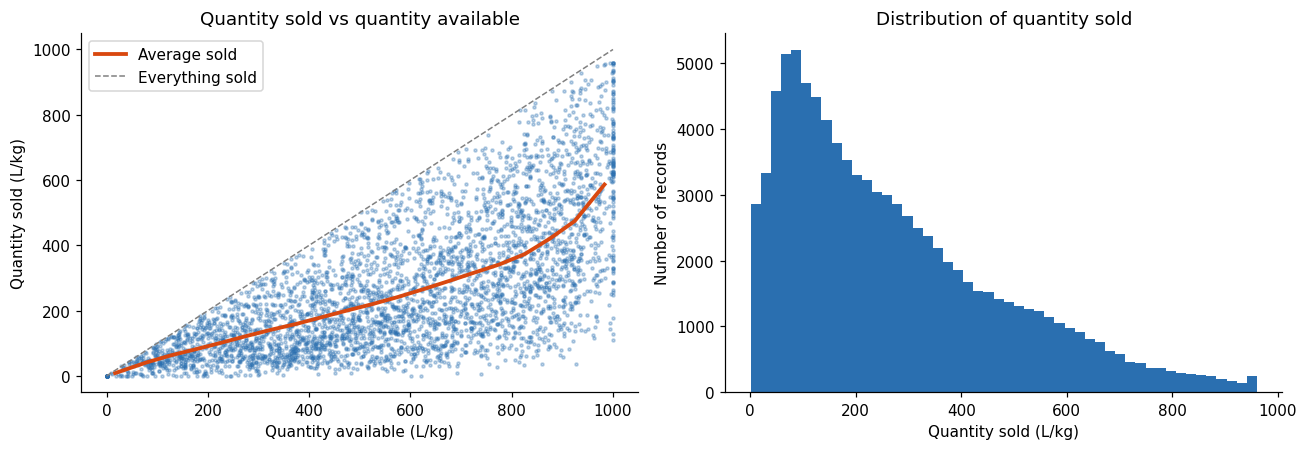

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
sample = data.sample(4000, random_state=RANDOM_STATE)
axes[0].scatter(sample.qty_available, sample.qty_sold, s=4, alpha=0.3, color=BLUE)
bins = data.groupby(pd.cut(data.qty_available, np.arange(0, 1001, 50)), observed=True)
axes[0].plot(bins.qty_available.mean(), bins.qty_sold.mean(), color=ORANGE, lw=2.5, label="Average sold")
axes[0].plot([0, 1000], [0, 1000], ls="--", color="grey", lw=1, label="Everything sold")
axes[0].set(title="Quantity sold vs quantity available", xlabel="Quantity available (L/kg)",
            ylabel="Quantity sold (L/kg)")
axes[0].legend()
axes[1].hist(data.qty_sold, bins=50, color=BLUE)
axes[1].set(title="Distribution of quantity sold", xlabel="Quantity sold (L/kg)", ylabel="Number of records")
plt.tight_layout(); plt.show()

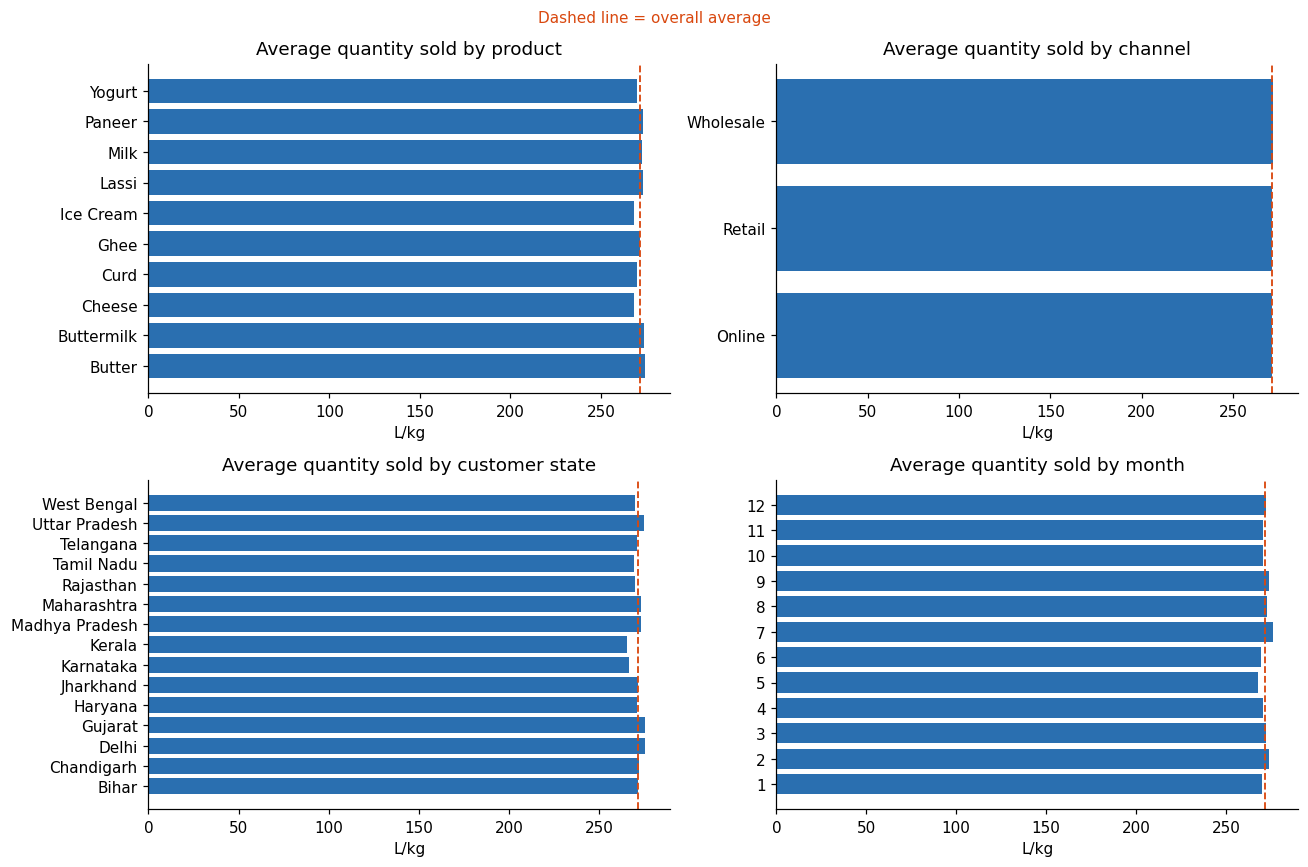

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), ["product", "channel", "customer_state", "month"]):
    avg = data.groupby(col)["qty_sold"].mean()
    ax.barh(avg.index.astype(str), avg.values, color=BLUE)
    ax.axvline(data.qty_sold.mean(), color=ORANGE, ls="--", lw=1.2)
    ax.set(title=f"Average quantity sold by {col.replace('_', ' ')}", xlabel="L/kg")
fig.suptitle("Dashed line = overall average", color=ORANGE, fontsize=10)
plt.tight_layout(); plt.show()

Quantity sold rises steadily with quantity available. The bars are almost identical across products, channels, states and months, so in these records **how much was made available is the only visible driver of sales**.

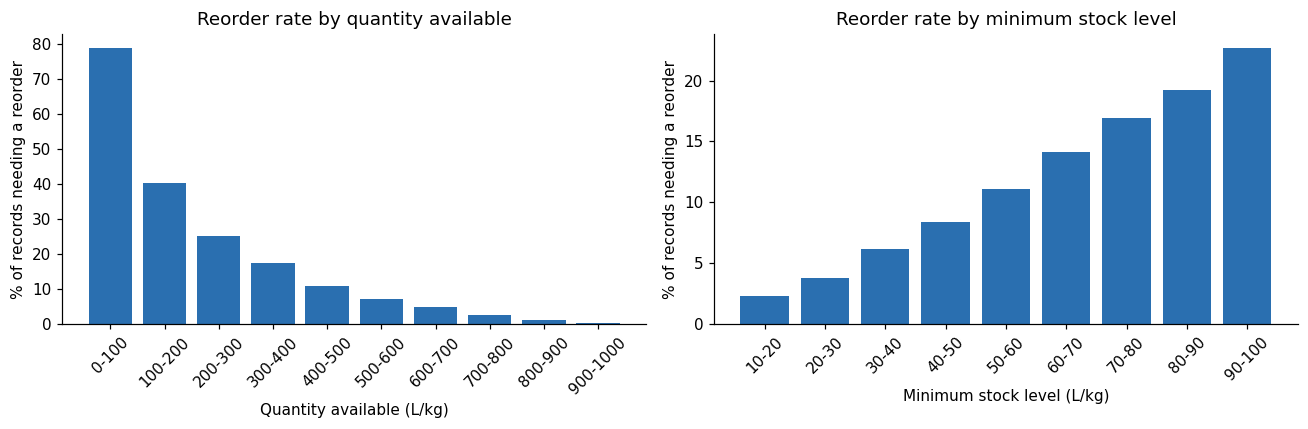

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, label, step in [(axes[0], "qty_available", "quantity available", 100),
                             (axes[1], "min_stock", "minimum stock level", 10)]:
    rate = data.groupby(pd.cut(data[col], np.arange(0, 1001, step)), observed=True)["needs_reorder"].mean()
    ax.bar([f"{int(i.left)}-{int(i.right)}" for i in rate.index], rate.values * 100, color=BLUE)
    ax.set(title=f"Reorder rate by {label}", xlabel=f"{label.capitalize()} (L/kg)",
           ylabel="% of records needing a reorder")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

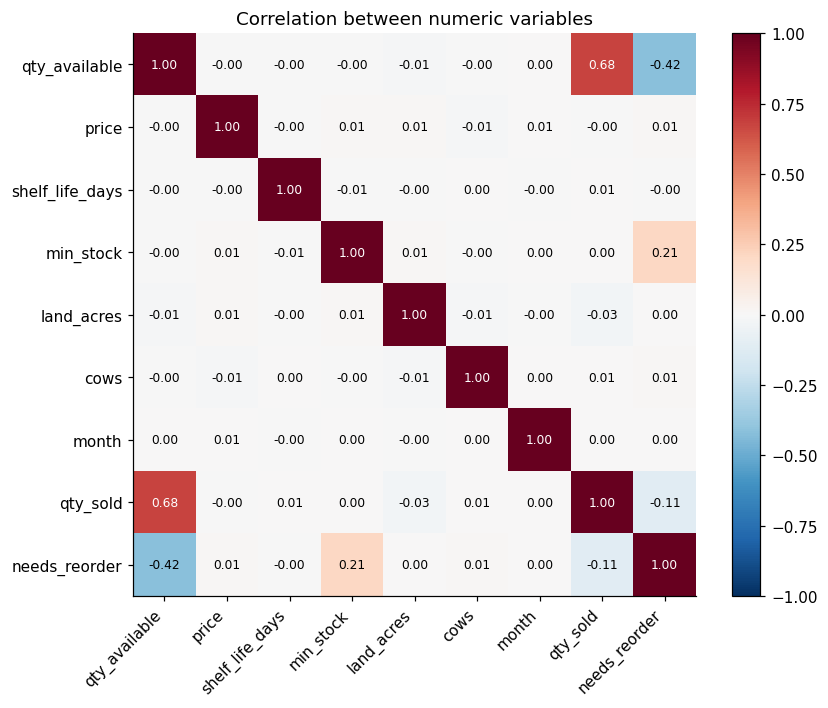

In [11]:
num_cols = ["qty_available", "price", "shelf_life_days", "min_stock", "land_acres", "cows", "month",
            "qty_sold", "needs_reorder"]
corr = data[num_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols)), num_cols, rotation=45, ha="right")
ax.set_yticks(range(len(num_cols)), num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(corr.iloc[i, j]) > 0.5 else "black")
fig.colorbar(im)
ax.set_title("Correlation between numeric variables")
plt.tight_layout(); plt.show()

Reorders are common when little stock is made available or when the minimum level is set high. In the correlation matrix, only `qty_available` (for sales and reorders) and `min_stock` (for reorders) stand out.

## Step 7 · Split by time: train on 2019–2021, test on 2022
Testing on a year the model never saw mirrors real use: learn from the past, predict the future.

In [12]:
train = data[data.year <= 2021].copy()
test = data[data.year == 2022].copy()
print(f"Train: {len(train):,} rows (2019-2021) | Test: {len(test):,} rows (2022)")

Train: 70,770 rows (2019-2021) | Test: 22,015 rows (2022)


## Step 8 · Linear regression: how much will sell?
### 8.1 Start with every input known before the sale

In [13]:
NUM_ALL = ["qty_available", "price", "shelf_life_days", "land_acres", "cows"]
CAT_ALL = ["product", "brand", "storage", "channel", "farm_state", "customer_state", "farm_size", "month"]

def clip_sales(pred, qty):
    # You cannot sell less than zero or more than you had
    return np.clip(np.asarray(pred, dtype=float), 0, np.asarray(qty, dtype=float))

def regression_scores(y_true, y_pred):
    return {"R2": float(r2_score(y_true, y_pred)), "MAE (L/kg)": float(mean_absolute_error(y_true, y_pred)),
            "RMSE (L/kg)": float(np.sqrt(mean_squared_error(y_true, y_pred)))}

model_A = Pipeline([
    ("prep", ColumnTransformer([("num", StandardScaler(), NUM_ALL),
                                ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_ALL)])),
    ("model", LinearRegression())])
model_A.fit(train[NUM_ALL + CAT_ALL], train.qty_sold)
pred_A = clip_sales(model_A.predict(test[NUM_ALL + CAT_ALL]), test.qty_available)
print("Model A (all 13 inputs), tested on 2022:", {k: round(v, 3) for k, v in regression_scores(test.qty_sold, pred_A).items()})

Model A (all 13 inputs), tested on 2022: {'R2': 0.461, 'MAE (L/kg)': 119.705, 'RMSE (L/kg)': 152.702}


### 8.2 Which inputs actually help?
Each input is added, one at a time, to a model that already contains quantity available. The **F-test** asks whether the improvement is statistically significant. The **extra R²** asks whether it is big enough to matter. With 70,000+ training rows, even trivial effects can be "significant", so for a manager the extra R² is what counts.

In [14]:
base_ols = smf.ols("qty_sold ~ qty_available", data=train).fit()
rows = []
for term in NUM_ALL[1:] + [f"C({c})" for c in CAT_ALL]:
    m = smf.ols(f"qty_sold ~ qty_available + {term}", data=train).fit()
    rows.append({"input added": term.replace("C(", "").replace(")", ""),
                 "extra R2 (percentage points)": 100 * (m.rsquared - base_ols.rsquared),
                 "F-test p-value": anova_lm(base_ols, m)["Pr(>F)"].iloc[1]})
print(f"R2 with quantity available alone: {base_ols.rsquared:.3f}")
pd.DataFrame(rows).sort_values("extra R2 (percentage points)", ascending=False).round(4).reset_index(drop=True)

R2 with quantity available alone: 0.462


,input added,extra R2 (percentage points),F-test p-value
0,land_acres,0.0598,0.0000
1,farm_state,0.0121,0.3187
2,channel,0.0113,0.0006
3,customer_state,0.0094,0.5771
4,product,0.0068,0.4395
5,brand,0.0062,0.6141
6,month,0.0043,0.8958
7,cows,0.0035,0.0314
8,shelf_life_days,0.0035,0.0326
9,storage,0.0028,0.4495


No input adds even 0.1 percentage points of R². A few pass the significance test only because the sample is huge, which is statistical significance without practical significance.

### 8.3 Compare candidate models on 2022 data
- **A**: all 13 inputs
- **B**: quantity available only (a straight line)
- **C**: quantity available, its square and its cube, with no intercept. Zero available means zero sold, and the share that sells can rise or fall with the quantity. This is still linear regression: the model is linear in its coefficients.

In [15]:
model_B = Pipeline([("model", LinearRegression())])
model_C = Pipeline([("powers", PolynomialFeatures(degree=3, include_bias=False)),
                    ("model", LinearRegression(fit_intercept=False))])
model_B.fit(train[["qty_available"]], train.qty_sold)
model_C.fit(train[["qty_available"]], train.qty_sold)

comparison = pd.DataFrame({
    "A: all 13 inputs": regression_scores(test.qty_sold, pred_A),
    "B: quantity only": regression_scores(test.qty_sold, clip_sales(model_B.predict(test[["qty_available"]]), test.qty_available)),
    "C: quantity, squared and cubed (through zero)": regression_scores(test.qty_sold, clip_sales(model_C.predict(test[["qty_available"]]), test.qty_available)),
}).T
comparison.round(3)

,R2,MAE (L/kg),RMSE (L/kg)
A: all 13 inputs,0.461,119.705,152.702
B: quantity only,0.461,119.713,152.761
"C: quantity, squared and cubed (through zero)",0.489,115.427,148.671


**Choice: model C.** It is the most accurate on 2022 data and needs only one input. The extra terms capture a pattern in the records: about half of small quantities sells, the share falls to around 42% in the middle range, and it rises again to about 60% for the largest quantities.

### 8.4 The final linear model
For readable coefficients, quantity is written in hundreds of L/kg (q = 4 means 400 L/kg). Without an intercept, statsmodels prints an "uncentred" R² that is not comparable with the others, so the usual R² is calculated separately.

In [16]:
sales_model = model_C
final_ols = smf.ols("qty_sold ~ I(qty_available / 100) + I((qty_available / 100) ** 2) "
                    "+ I((qty_available / 100) ** 3) - 1", data=train).fit()
print(final_ols.summary().tables[1])
b1, b2, b3 = (float(v) for v in final_ols.params)
train_r2 = r2_score(train.qty_sold, clip_sales(sales_model.predict(train[["qty_available"]]), train.qty_available))
print(f"\nR2: {train_r2:.3f} on training data (2019-2021), {comparison.iloc[2]['R2']:.3f} on test data (2022)")
print(f"Expected quantity sold = {b1:.2f} q {b2:+.2f} q^2 {b3:+.3f} q^3   (q = quantity available in hundreds of L/kg)")

                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
I(qty_available / 100)           67.8902      1.006     67.476      0.000      65.918      69.862
I((qty_available / 100) ** 2)   -10.0668      0.300    -33.546      0.000     -10.655      -9.479
I((qty_available / 100) ** 3)     0.9150      0.021     42.603      0.000       0.873       0.957

R2: 0.490 on training data (2019-2021), 0.489 on test data (2022)
Expected quantity sold = 67.89 q -10.07 q^2 +0.915 q^3   (q = quantity available in hundreds of L/kg)


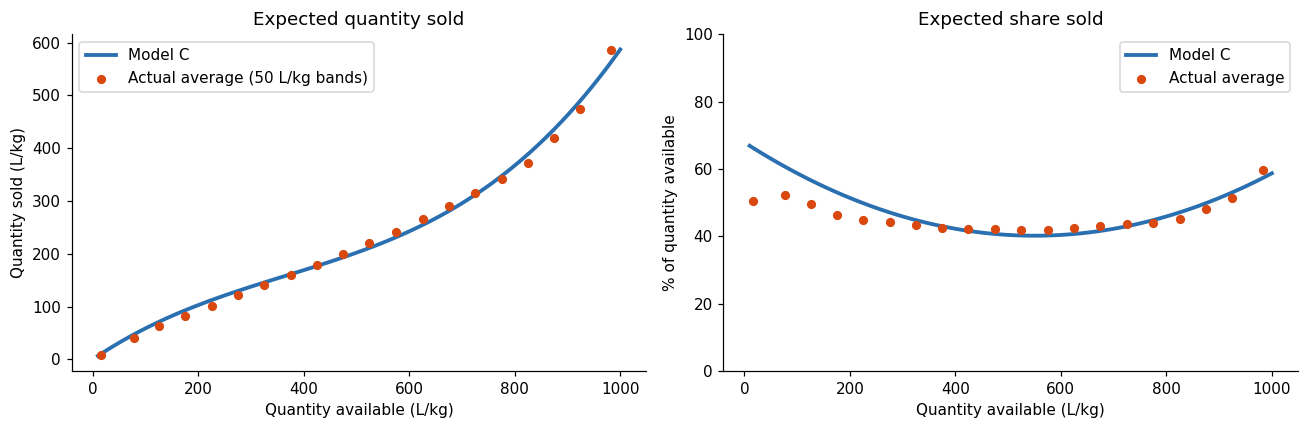

In [17]:
# How well does the curve follow the actual averages?
grid = np.linspace(10, 1000, 100)
curve = clip_sales(sales_model.predict(pd.DataFrame({"qty_available": grid})), grid)
bins = data.groupby(pd.cut(data.qty_available, np.arange(0, 1001, 50)), observed=True)
avg_q, avg_sold = bins.qty_available.mean(), bins.qty_sold.mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(grid, curve, color=BLUE, lw=2.5, label="Model C")
axes[0].scatter(avg_q, avg_sold, color=ORANGE, s=25, zorder=3, label="Actual average (50 L/kg bands)")
axes[0].set(title="Expected quantity sold", xlabel="Quantity available (L/kg)", ylabel="Quantity sold (L/kg)")
axes[0].legend()
axes[1].plot(grid, 100 * curve / grid, color=BLUE, lw=2.5, label="Model C")
axes[1].scatter(avg_q, 100 * avg_sold / avg_q, color=ORANGE, s=25, zorder=3, label="Actual average")
axes[1].set(title="Expected share sold", xlabel="Quantity available (L/kg)", ylabel="% of quantity available",
            ylim=(0, 100))
axes[1].legend()
plt.tight_layout(); plt.show()

The curve follows the actual averages closely in litres. In share terms it overstates small quantities (below about 250 L/kg) by up to 10–15 points. That is only a few litres, because the model is fitted to litres sold, not to the share.

In [18]:
examples = pd.DataFrame({"qty_available": [100, 250, 500, 750, 1000]})
examples["expected_sold"] = clip_sales(sales_model.predict(examples[["qty_available"]]), examples.qty_available).round(0)
examples["expected_sell_through_%"] = (100 * examples.expected_sold / examples.qty_available).round(0)
examples

,qty_available,expected_sold,expected_sell_through_%
0,100,59.0,59.0
1,250,121.0,48.0
2,500,202.0,40.0
3,750,329.0,44.0
4,1000,587.0,59.0


### 8.5 Check the errors and build a "likely range"
The errors spread out as quantity available grows (a fan shape in the left chart), so a single ± figure would mislead. For each 100 L/kg band, we record the range that held the middle 80% of training errors and blend smoothly between bands. Then we check how often 2022 sales fell inside it.

2022 records inside the likely range: 80% (aim: about 80%)


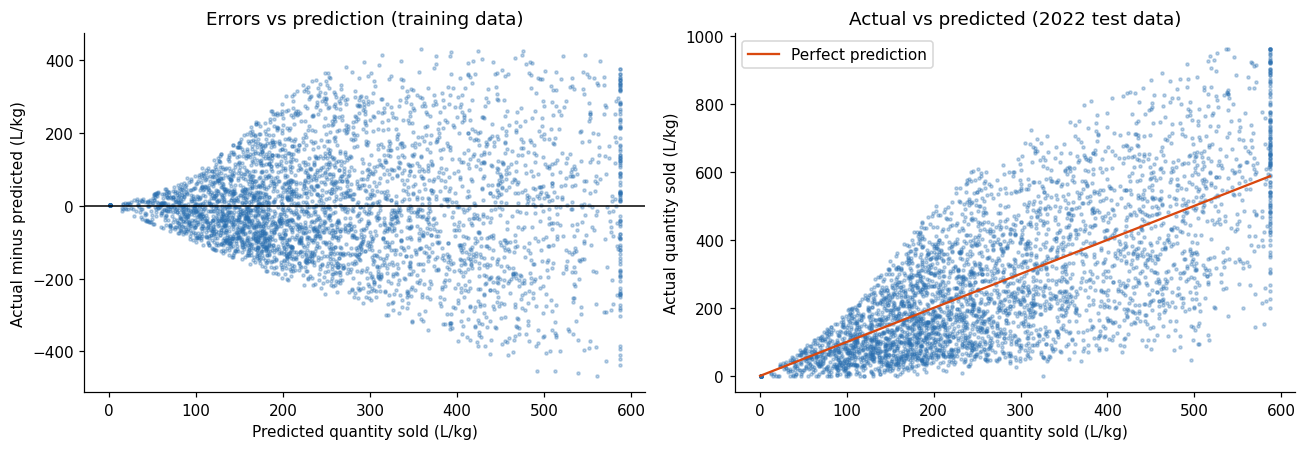

In [19]:
train_pred = clip_sales(sales_model.predict(train[["qty_available"]]), train.qty_available)
test_pred = clip_sales(sales_model.predict(test[["qty_available"]]), test.qty_available)
resid = train.qty_sold.values - train_pred

BANDS = np.arange(0, 1001, 100)
RANGE_QTY = [float(m) for m in (BANDS[:-1] + BANDS[1:]) / 2]      # band mid-points: 50, 150, ... 950
band_train = np.clip(np.searchsorted(BANDS, train.qty_available.values, side="left") - 1, 0, len(BANDS) - 2)
RANGE_LOW = [float(np.quantile(resid[band_train == b], 0.10)) for b in range(len(BANDS) - 1)]
RANGE_HIGH = [float(np.quantile(resid[band_train == b], 0.90)) for b in range(len(BANDS) - 1)]

def likely_range(qty, pred):
    low = pred + np.interp(qty, RANGE_QTY, RANGE_LOW)
    high = pred + np.interp(qty, RANGE_QTY, RANGE_HIGH)
    return np.clip(low, 0, qty), np.clip(high, 0, qty)

low, high = likely_range(test.qty_available.values, test_pred)
coverage = np.mean((test.qty_sold.values >= low) & (test.qty_sold.values <= high))
print(f"2022 records inside the likely range: {coverage:.0%} (aim: about 80%)")

rng = np.random.default_rng(RANDOM_STATE)
i_tr, i_te = rng.choice(len(train), 4000, replace=False), rng.choice(len(test), 4000, replace=False)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].scatter(train_pred[i_tr], resid[i_tr], s=4, alpha=0.3, color=BLUE)
axes[0].axhline(0, color="black", lw=1)
axes[0].set(title="Errors vs prediction (training data)", xlabel="Predicted quantity sold (L/kg)",
            ylabel="Actual minus predicted (L/kg)")
axes[1].scatter(test_pred[i_te], test.qty_sold.values[i_te], s=4, alpha=0.3, color=BLUE)
top = float(test_pred.max())
axes[1].plot([0, top], [0, top], color=ORANGE, lw=1.5, label="Perfect prediction")
axes[1].set(title="Actual vs predicted (2022 test data)", xlabel="Predicted quantity sold (L/kg)",
            ylabel="Actual quantity sold (L/kg)")
axes[1].legend()
plt.tight_layout(); plt.show()

## Step 9 · Logistic regression: will a reorder be needed?
### 9.1 All inputs vs the two stock inputs

In [20]:
LOG_NUM_ALL = ["qty_available", "min_stock", "price", "shelf_life_days", "land_acres", "cows"]
LOG_COLS = ["qty_available", "min_stock"]

logit_all = Pipeline([
    ("prep", ColumnTransformer([("num", StandardScaler(), LOG_NUM_ALL),
                                ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_ALL)])),
    ("model", LogisticRegression(max_iter=2000))])
reorder_model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=2000))])

logit_all.fit(train[LOG_NUM_ALL + CAT_ALL], train.needs_reorder)
reorder_model.fit(train[LOG_COLS], train.needs_reorder)
auc_all = roc_auc_score(test.needs_reorder, logit_all.predict_proba(test[LOG_NUM_ALL + CAT_ALL])[:, 1])
auc_two = roc_auc_score(test.needs_reorder, reorder_model.predict_proba(test[LOG_COLS])[:, 1])
print(f"AUC on 2022 with all 14 inputs: {auc_all:.3f}")
print(f"AUC on 2022 with quantity available + minimum stock only: {auc_two:.3f}")

short = data.qty_available <= data.min_stock
print(f"\nRecords where no more than the minimum level was made available: {short.sum():,}. "
      f"Share that needed a reorder: {data.loc[short, 'needs_reorder'].mean():.0%}")

AUC on 2022 with all 14 inputs: 0.895
AUC on 2022 with quantity available + minimum stock only: 0.896

Records where no more than the minimum level was made available: 1,313. Share that needed a reorder: 100%


The two stock inputs do as well as all fourteen, so the simpler model is kept. **AUC** is the chance that the model gives a higher risk to a record that needed a reorder than to one that did not (0.5 = guessing, 1.0 = perfect).

If no more than the minimum level is made available, closing stock must end below it, so a reorder is certain. A smooth logistic curve cannot show that jump, so the Streamlit app applies it as a business rule on top of the model.

### 9.2 Odds ratios

In [21]:
logit_sm = smf.logit("needs_reorder ~ qty_available + min_stock", data=train).fit(disp=0)
print(logit_sm.summary())
odds_100_qty = float(np.exp(100 * logit_sm.params["qty_available"]))
odds_10_min = float(np.exp(10 * logit_sm.params["min_stock"]))
print(f"\nEach extra 100 L/kg available multiplies the odds of a reorder by {odds_100_qty:.2f} "
      f"({(odds_100_qty - 1):+.0%}).")
print(f"Each extra 10 L/kg of minimum stock multiplies the odds of a reorder by {odds_10_min:.2f} "
      f"({(odds_10_min - 1):+.0%}).")

                           Logit Regression Results                           
Dep. Variable:          needs_reorder   No. Observations:                70770
Model:                          Logit   Df Residuals:                    70767
Method:                           MLE   Df Model:                            2
Date:                Mon, 28 Sep 2026   Pseudo R-squ.:                  0.3398
Time:                        17:56:50   Log-Likelihood:                -17064.
converged:                       True   LL-Null:                       -25849.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -1.2490      0.043    -28.745      0.000      -1.334      -1.164
qty_available    -0.0069   7.47e-05    -91.748      0.000      -0.007      -0.007
min_stock         0.0358      0.001     

### 9.3 Choose the alert level using training data only
Only about 12% of records needed a reorder, so the usual 50% cut-off would miss most of them. The cut-off below gives the best balance of precision and recall (the F1 score) in 5-fold cross-validation **on the training data only**, so the 2022 test stays untouched.

In [22]:
oof = cross_val_predict(reorder_model, train[LOG_COLS], train.needs_reorder, method="predict_proba",
                        cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE))[:, 1]
prec, rec, thr = precision_recall_curve(train.needs_reorder, oof)
f1 = 2 * prec * rec / (prec + rec + 1e-12)
ALERT_CUTOFF = float(thr[np.argmax(f1[:-1])])
print(f"Alert when the chance of a reorder is at least {ALERT_CUTOFF:.0%}")

Alert when the chance of a reorder is at least 30%


### 9.4 Test on 2022

In [23]:
p_test = reorder_model.predict_proba(test[LOG_COLS])[:, 1]
def classification_scores(cut):
    y_hat = (p_test >= cut).astype(int)
    return {"accuracy": accuracy_score(test.needs_reorder, y_hat),
            "precision (alerts that were right)": precision_score(test.needs_reorder, y_hat),
            "recall (reorders caught)": recall_score(test.needs_reorder, y_hat),
            "F1": f1_score(test.needs_reorder, y_hat)}

print(f"Share of 2022 records that needed a reorder: {test.needs_reorder.mean():.1%} "
      f"(a model that never alerts would be {1 - test.needs_reorder.mean():.1%} 'accurate')")
pd.DataFrame({f"alert at {ALERT_CUTOFF:.0%}": classification_scores(ALERT_CUTOFF),
              "alert at 50%": classification_scores(0.5)}).round(3)

Share of 2022 records that needed a reorder: 11.5% (a model that never alerts would be 88.5% 'accurate')


,alert at 30%,alert at 50%
accuracy,0.890,0.907
precision (alerts that were right),0.519,0.670
recall (reorders caught),0.617,0.375
F1,0.564,0.481


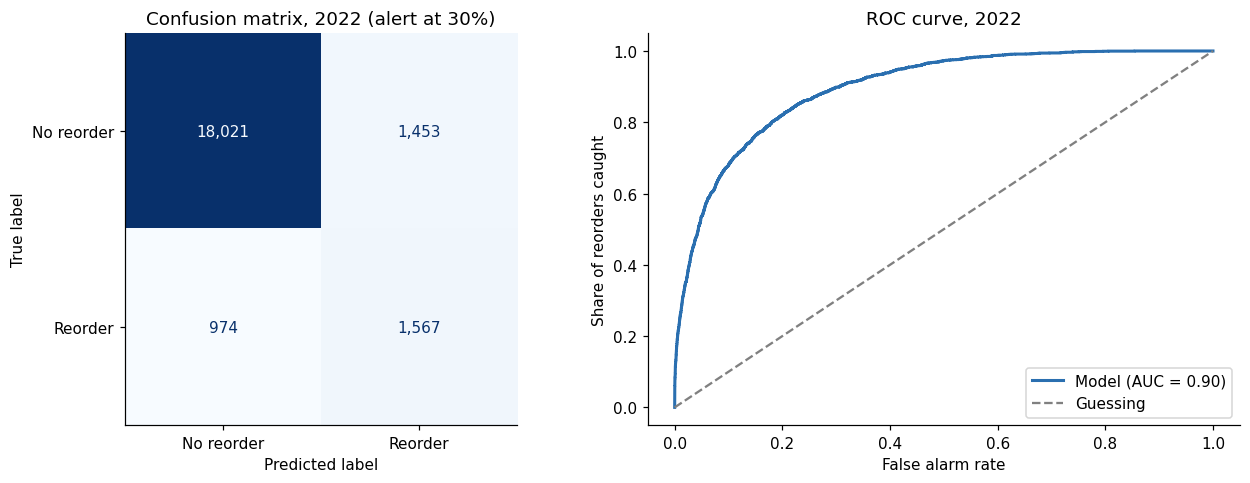

,records,actual_reorder_rate,predicted_chance
band,,,
"(0, 100]",689,0.798,0.576
"(100, 200]",1349,0.406,0.440
"(200, 300]",1759,0.256,0.318
"(300, 500]",4512,0.135,0.157
"(500, 1000]",13706,0.028,0.026


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay.from_predictions(test.needs_reorder, (p_test >= ALERT_CUTOFF).astype(int),
                                        display_labels=["No reorder", "Reorder"], cmap="Blues",
                                        values_format=",", ax=axes[0], colorbar=False)
axes[0].set_title(f"Confusion matrix, 2022 (alert at {ALERT_CUTOFF:.0%})")
fpr, tpr, _ = roc_curve(test.needs_reorder, p_test)
axes[1].plot(fpr, tpr, color=BLUE, lw=2, label=f"Model (AUC = {auc_two:.2f})")
axes[1].plot([0, 1], [0, 1], ls="--", color="grey", label="Guessing")
axes[1].set(title="ROC curve, 2022", xlabel="False alarm rate", ylabel="Share of reorders caught")
axes[1].legend()
plt.tight_layout(); plt.show()

# Do the predicted chances match what actually happened?
calib = pd.DataFrame({"band": pd.cut(test.qty_available, [0, 100, 200, 300, 500, 1000]),
                      "actual": test.needs_reorder, "predicted": p_test})
calib.groupby("band", observed=True).agg(records=("actual", "size"), actual_reorder_rate=("actual", "mean"),
                                         predicted_chance=("predicted", "mean")).round(3)

## Step 10 · What this means for ABC Ltd

In [25]:
sales_scores = regression_scores(test.qty_sold, test_pred)
alert = classification_scores(ALERT_CUTOFF)
print("1. SALES FOLLOW SUPPLY. Quantity available is the only input that predicts how much sells.")
print(f"   The sales model explains {sales_scores['R2']:.0%} of the variation in 2022 sales; typical error "
      f"+/-{sales_scores['MAE (L/kg)']:.0f} L/kg.")
print(f"   Expected share sold: about {examples['expected_sell_through_%'].iloc[0]:.0f}% at 100 L/kg, "
      f"{examples['expected_sell_through_%'].iloc[2]:.0f}% at 500 L/kg and {examples['expected_sell_through_%'].iloc[-1]:.0f}% at 1,000 L/kg.")
print("2. PRICE, PRODUCT, CHANNEL, REGION AND SEASON SHOW NO EFFECT in these records (adding them lifts R2 "
      "by less than 0.1 percentage points).")
print(f"3. REORDER RISK is driven by how much is made available and how high the minimum level is set: "
      f"+100 L/kg available cuts the odds by {1 - odds_100_qty:.0%}; +10 L/kg of minimum stock raises them by {odds_10_min - 1:.0%}.")
print(f"4. THE REORDER ALERT catches {alert['recall (reorders caught)']:.0%} of the reorders that happened in 2022; "
      f"{alert['precision (alerts that were right)']:.0%} of alerts were right (AUC {auc_two:.2f}).")

1. SALES FOLLOW SUPPLY. Quantity available is the only input that predicts how much sells.
   The sales model explains 49% of the variation in 2022 sales; typical error +/-115 L/kg.
   Expected share sold: about 59% at 100 L/kg, 40% at 500 L/kg and 59% at 1,000 L/kg.
2. PRICE, PRODUCT, CHANNEL, REGION AND SEASON SHOW NO EFFECT in these records (adding them lifts R2 by less than 0.1 percentage points).
3. REORDER RISK is driven by how much is made available and how high the minimum level is set: +100 L/kg available cuts the odds by 50%; +10 L/kg of minimum stock raises them by 43%.
4. THE REORDER ALERT catches 62% of the reorders that happened in 2022; 52% of alerts were right (AUC 0.90).


**Limitations to state in your report**
1. The audit found records that cannot happen in a real business (sales above available stock, expiry before production, the same price range for every product). The dataset appears to be generated or heavily processed, so the results demonstrate the *method* rather than real customer behaviour.
2. Price, product, channel, region and season show no effect here. In a real dairy business they would, so a model built on live company data would need them.
3. The sales model explains just under half of the variation in quantity sold. Managers should plan with the likely range, not the single number.
4. At the chosen alert level, a good share of alerts are false alarms (see 9.4). That trade-off was chosen to catch more real reorders.

## Step 11 · Save the models for the Streamlit app
This saves both models and the facts the app displays into one file, `abc_ltd_models.joblib`. It also writes a `requirements.txt` that pins the same scikit-learn and numpy versions used here. **Always upload these two files to GitHub together, from the same run.**

In [26]:
meta = {
    "company": "ABC Ltd",
    "rows_raw": int(len(df)), "rows_clean": int(len(data)), "rows_removed": int(len(df) - len(data)),
    "rows_train": int(len(train)), "rows_test": int(len(test)),
    "train_period": "2019-2021", "test_period": "2022",
    "qty_range": [float(data.qty_available.min()), float(data.qty_available.max())],
    "min_stock_range": [float(data.min_stock.min()), float(data.min_stock.max())],
    "price_range": [float(data.price.min()), float(data.price.max())],
    "defaults": {"qty_available": float(data.qty_available.median()), "min_stock": float(data.min_stock.median()),
                 "price": float(data.price.median())},
    "sales": {"r2": float(sales_scores["R2"]), "mae": float(sales_scores["MAE (L/kg)"]),
              "rmse": float(sales_scores["RMSE (L/kg)"]),
              "range_qty": RANGE_QTY, "range_low": RANGE_LOW, "range_high": RANGE_HIGH,
              "range_coverage": float(coverage), "r2_all_inputs": float(comparison.iloc[0]["R2"])},
    "reorder": {"auc": float(auc_two), "auc_all_inputs": float(auc_all), "alert_cutoff": ALERT_CUTOFF,
                "recall": float(alert["recall (reorders caught)"]),
                "precision": float(alert["precision (alerts that were right)"]),
                "accuracy": float(alert["accuracy"]), "base_rate": float(test.needs_reorder.mean()),
                "odds_per_100_qty": odds_100_qty, "odds_per_10_min_stock": odds_10_min},
    "no_effect_inputs": ["price", "product", "brand", "storage condition", "shelf life", "sales channel",
                         "farm state", "customer state", "farm size", "land area", "herd size", "month"],
    "versions": {"python": sys.version.split()[0], "scikit-learn": sklearn.__version__, "numpy": np.__version__},
}
joblib.dump({"sales_model": sales_model, "reorder_model": reorder_model, "meta": meta}, "abc_ltd_models.joblib")

with open("requirements.txt", "w") as f:
    f.write("streamlit==1.64.0\n"
            f"scikit-learn=={sklearn.__version__}\n"
            f"numpy=={np.__version__}\n"
            "pandas\naltair\njoblib\n")

# Reload the saved file and predict one example, to prove it works
check = joblib.load("abc_ltd_models.joblib")
q, m = 400, 55
sold = float(clip_sales(check["sales_model"].predict(pd.DataFrame({"qty_available": [q]})), q)[0])
risk = float(check["reorder_model"].predict_proba(pd.DataFrame({"qty_available": [q], "min_stock": [m]}))[0, 1])
print(f"Check: {q} L/kg available, minimum stock {m} -> expected sold {sold:.0f} L/kg, reorder chance {risk:.0%}")

with zipfile.ZipFile("abc_ltd_model_files.zip", "w") as z:
    z.write("abc_ltd_models.joblib")
    z.write("requirements.txt")
print(open("requirements.txt").read())
print(f"On Streamlit, open Advanced settings and choose Python {sys.version_info.major}.{sys.version_info.minor}.")

if IN_COLAB:
    from google.colab import files
    files.download("abc_ltd_model_files.zip")

Check: 400 L/kg available, minimum stock 55 -> expected sold 169 L/kg, reorder chance 12%
streamlit==1.64.0
scikit-learn==1.8.0
numpy==2.4.4
pandas
altair
joblib

On Streamlit, open Advanced settings and choose Python 3.11.


## Next: GitHub and Streamlit
1. Unzip `abc_ltd_model_files.zip`. It contains `abc_ltd_models.joblib` and `requirements.txt`.
2. Upload both to your GitHub repository, together with `app.py` and `README.md`.
3. Deploy on share.streamlit.io and choose the Python version printed above.

`README.md` has the full steps.